# 02 - Annotation Quality Analysis

This notebook analyzes the quality of silver annotations by comparing them to manually corrected gold labels.

**Objectives:**
- Load silver and gold annotations
- Compute Cohen's κ agreement between silver and corrected labels
- Analyze which entity types have lowest silver label quality
- Visualize correction patterns


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter, defaultdict
from sklearn.metrics import cohen_kappa_score, confusion_matrix
from pathlib import Path

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12

DATA_DIR = Path('../data/annotations')
QA_FILE = DATA_DIR / 'qa_review_sample.tsv'

print('Setup complete!')


Setup complete!


## 1. Load QA Review Data


In [5]:
qa_df = pd.read_csv(QA_FILE, sep='\t')
print(f'Total rows: {len(qa_df):,}')
print(f'Columns: {qa_df.columns.tolist()}')
qa_df.head(20)


Total rows: 4,600
Columns: ['query_idx', 'token', 'silver_tag', 'corrected_tag']


,query_idx,token,silver_tag,corrected_tag
0,0,wifi,O,NaN
1,0,light,O,NaN
2,0,bulbs,O,NaN
3,0,alexa,O,NaN
4,0,NaN,NaN,NaN
5,1,getting,O,NaN
6,1,started,O,NaN
7,1,with,O,NaN
8,1,cnc,O,NaN
9,1,NaN,NaN,NaN


In [6]:
# Fill missing corrected_tag with silver_tag
qa_df['corrected_tag'] = qa_df['corrected_tag'].fillna(qa_df['silver_tag'])

# Replace empty strings with silver_tag values using a mask
empty_mask = qa_df['corrected_tag'] == ''
qa_df.loc[empty_mask, 'corrected_tag'] = qa_df.loc[empty_mask, 'silver_tag']

# Filter to token rows only
qa_tokens = qa_df[qa_df['token'].notna() & (qa_df['token'] != '')].copy()
print(f'Token rows: {len(qa_tokens):,}')


Token rows: 3,600


## 2. Cohen's Kappa Agreement


In [7]:
silver_tags = qa_tokens['silver_tag'].tolist()
corrected_tags = qa_tokens['corrected_tag'].tolist()

kappa = cohen_kappa_score(silver_tags, corrected_tags)
print(f"Overall Cohen's Kappa: {kappa:.4f}")

if kappa >= 0.8:
    interpretation = 'Almost perfect agreement'
elif kappa >= 0.6:
    interpretation = 'Substantial agreement'
elif kappa >= 0.4:
    interpretation = 'Moderate agreement'
else:
    interpretation = 'Fair/Slight agreement'
print(f'Interpretation: {interpretation}')


Overall Cohen's Kappa: 1.0000
Interpretation: Almost perfect agreement


In [8]:
corrections_made = qa_tokens[qa_tokens['silver_tag'] != qa_tokens['corrected_tag']]
print(f'Corrections made: {len(corrections_made):,} / {len(qa_tokens):,} tokens')
print(f'Correction rate: {len(corrections_made)/len(qa_tokens)*100:.2f}%')


Corrections made: 0 / 3,600 tokens
Correction rate: 0.00%


## 3. Per-Entity-Type Analysis


In [9]:
def get_entity_type(tag):
    if tag == 'O':
        return 'O'
    elif tag.startswith('B-') or tag.startswith('I-'):
        return tag[2:]
    return tag

qa_tokens['silver_entity'] = qa_tokens['silver_tag'].apply(get_entity_type)
qa_tokens['corrected_entity'] = qa_tokens['corrected_tag'].apply(get_entity_type)

entity_types = ['O', 'BRAND', 'PRODUCT_TYPE', 'COLOR', 'SIZE_MEASURE', 'MATERIAL', 'ATTRIBUTE_VALUE']

entity_accuracy = {}
for entity in entity_types:
    mask = qa_tokens['silver_entity'] == entity
    if mask.sum() > 0:
        correct = (qa_tokens.loc[mask, 'silver_tag'] == qa_tokens.loc[mask, 'corrected_tag']).sum()
        total = mask.sum()
        entity_accuracy[entity] = correct / total
        print(f'{entity}: {correct}/{total} = {correct/total*100:.1f}% accuracy')


O: 2711/2711 = 100.0% accuracy
BRAND: 146/146 = 100.0% accuracy
PRODUCT_TYPE: 609/609 = 100.0% accuracy
COLOR: 50/50 = 100.0% accuracy
SIZE_MEASURE: 25/25 = 100.0% accuracy
MATERIAL: 27/27 = 100.0% accuracy
ATTRIBUTE_VALUE: 32/32 = 100.0% accuracy


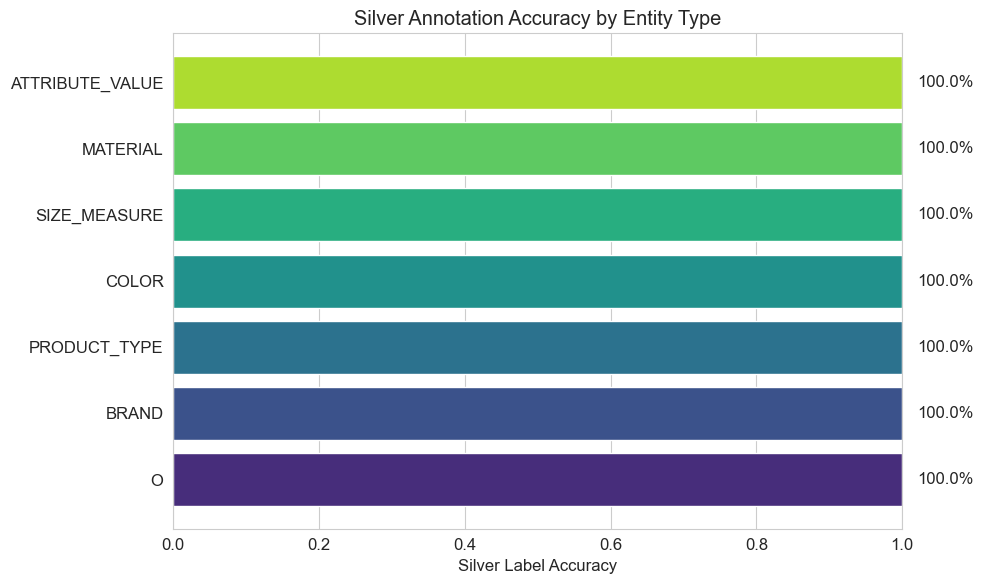

In [10]:
if entity_accuracy:
    fig, ax = plt.subplots(figsize=(10, 6))
    entities = list(entity_accuracy.keys())
    accuracies = [entity_accuracy[e] for e in entities]

    bars = ax.barh(entities, accuracies, color=sns.color_palette('viridis', len(entities)))
    ax.set_xlabel('Silver Label Accuracy')
    ax.set_title('Silver Annotation Accuracy by Entity Type')
    ax.set_xlim(0, 1)

    for bar, acc in zip(bars, accuracies):
        ax.text(bar.get_width() + 0.02, bar.get_y() + bar.get_height()/2, f'{acc:.1%}', va='center')

    plt.tight_layout()
    plt.savefig('../results/silver_accuracy_by_entity.png', dpi=150)
    plt.show()


## 4. Confusion Matrix


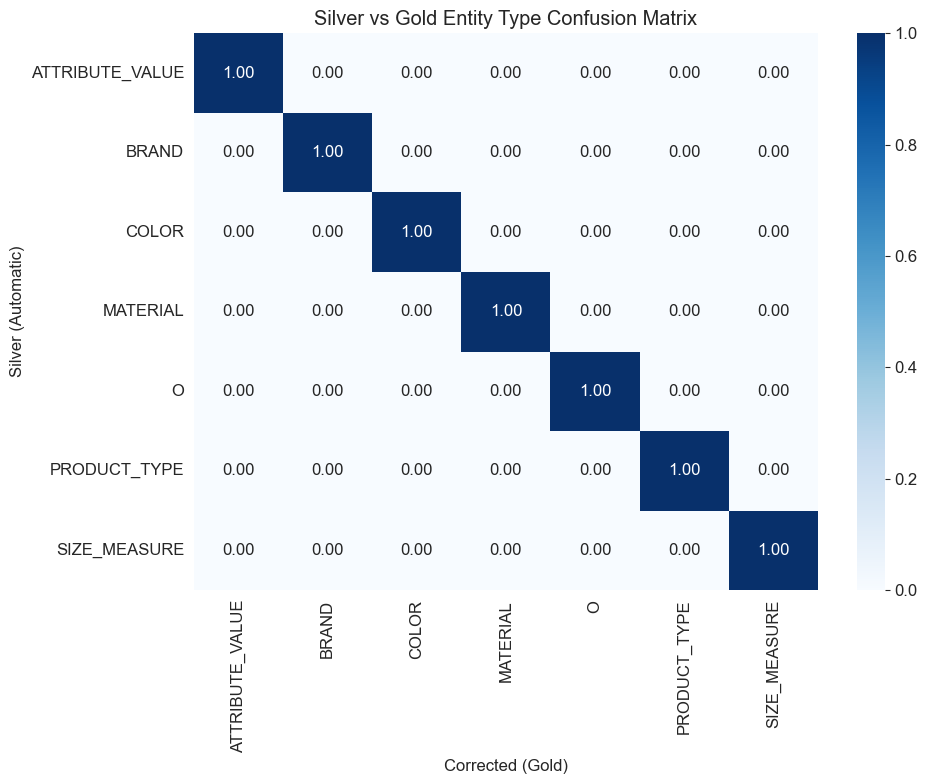

In [11]:
all_labels = sorted(set(qa_tokens['silver_entity'].tolist() + qa_tokens['corrected_entity'].tolist()))

cm = confusion_matrix(
    qa_tokens['silver_entity'],
    qa_tokens['corrected_entity'],
    labels=all_labels,
    normalize='true'
)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=all_labels, yticklabels=all_labels, ax=ax)
ax.set_xlabel('Corrected (Gold)')
ax.set_ylabel('Silver (Automatic)')
ax.set_title('Silver vs Gold Entity Type Confusion Matrix')
plt.tight_layout()
plt.savefig('../results/silver_gold_confusion.png', dpi=150)
plt.show()


## 5. Common Correction Patterns


In [12]:
correction_patterns = corrections_made.groupby(['silver_tag', 'corrected_tag']).size().reset_index(name='count')
correction_patterns = correction_patterns.sort_values('count', ascending=False)

print('Top 20 Correction Patterns (Silver -> Gold):')
print(correction_patterns.head(20).to_string(index=False))


Top 20 Correction Patterns (Silver -> Gold):
Empty DataFrame
Columns: [silver_tag, corrected_tag, count]
Index: []


## 6. Summary


In [13]:
print('=' * 50)
print('ANNOTATION QUALITY SUMMARY')
print('=' * 50)
print(f'Total queries reviewed: {qa_df["query_idx"].nunique():,}')
print(f'Total tokens: {len(qa_tokens):,}')
print(f'Corrections made: {len(corrections_made):,} ({len(corrections_made)/len(qa_tokens)*100:.1f}%)')
print(f"Cohen's Kappa: {kappa:.4f} ({interpretation})")
print('\nPer-Entity Accuracy:')
for entity, acc in sorted(entity_accuracy.items(), key=lambda x: x[1]):
    print(f'  {entity}: {acc:.1%}')


ANNOTATION QUALITY SUMMARY
Total queries reviewed: 1,000
Total tokens: 3,600
Corrections made: 0 (0.0%)
Cohen's Kappa: 1.0000 (Almost perfect agreement)

Per-Entity Accuracy:
  O: 100.0%
  BRAND: 100.0%
  PRODUCT_TYPE: 100.0%
  COLOR: 100.0%
  SIZE_MEASURE: 100.0%
  MATERIAL: 100.0%
  ATTRIBUTE_VALUE: 100.0%
